# CBOW

Este notebook implementa, de forma didática, o **Continuous Bag-of-Words (CBOW)** em PyTorch, conforme descrito no artigo **Efficient Estimation of Word Representations in Vector Space,2013**.

## Ideia central do CBOW

No CBOW, usamos as palavras ao redor de uma posição para prever a palavra central.
A formulação didática deste notebook segue a intuição central descrita no artigo:

- remover a camada oculta não linear
- compartilhar a projeção das palavras do contexto
- agregar os vetores do contexto por média
- prever a palavra alvo a partir das palavras vizinhas

Para manter o notebook simples e claro, aqui usamos **softmax completo** em vez de otimizações como hierarchical softmax ou negative sampling. Assim como é feito no primeiro artigo proposto.


In [1]:

import re
import random
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda



## 1. Corpus didático

Usamos um corpus pequeno apenas para fins pedagógicos. Em um cenário real, você trocaria esse corpus por um conjunto muito maior de textos.


In [3]:

base_sentences = [
    "the king is a man and the queen is a woman",
    "the prince is a man and the princess is a woman",
    "the king rules the kingdom and the queen rules the palace",
    "the prince lives in the palace and the princess lives in the castle",
    "the cat is a domestic animal and the dog is a domestic animal",
    "the cat likes milk and the dog likes bone",
    "python is a programming language",
    "pytorch is a deep learning library for python",
    "machine learning uses data and models",
    "neural networks learn patterns from data",
]

repeat_factor = 100
corpus = " ".join(base_sentences * repeat_factor)


#transforma todas a palavras em minusculas e encontra os caracteres alfa numericos(separa em palavras)
def tokenize(text: str):
    return re.findall(r"\b\w+\b", text.lower())


tokens = tokenize(corpus)
counter = Counter(tokens)
vocab = ["<UNK>"] + sorted(counter.keys())
stoi = {word: idx for idx, word in enumerate(vocab)}
itos = {idx: word for word, idx in stoi.items()}


def encode(word: str) -> int:
    return stoi.get(word, 0)


def decode(idx: int) -> str:
    return itos[idx]


print("Número de tokens:", len(tokens))
print("Tamanho do vocabulário:", len(vocab))
print("Primeiros tokens:", tokens[:20])


Número de tokens: 9300
Tamanho do vocabulário: 41
Primeiros tokens: ['the', 'king', 'is', 'a', 'man', 'and', 'the', 'queen', 'is', 'a', 'woman', 'the', 'prince', 'is', 'a', 'man', 'and', 'the', 'princess', 'is']



## 2. Construindo pares de treino

Se `window_size = 2`, cada exemplo usa:

- 2 palavras à esquerda
- 2 palavras à direita

para prever a palavra central.


In [4]:

window_size = 2 #conforme descrito no paper
contexts = []
targets = []

for i in range(window_size, len(tokens) - window_size):
    left_context = tokens[i - window_size:i]
    right_context = tokens[i + 1:i + window_size + 1]
    context_words = left_context + right_context
    target_word = tokens[i]

    contexts.append([encode(w) for w in context_words])
    targets.append(encode(target_word))

print("Quantidade de exemplos:", len(targets))
print("Exemplo de contexto:", [decode(x) for x in contexts[0]])
print("Palavra alvo:", decode(targets[0]))


Quantidade de exemplos: 9296
Exemplo de contexto: ['the', 'king', 'a', 'man']
Palavra alvo: is


In [5]:

class CBOWDataset(Dataset):
    def __init__(self, contexts, targets):
        self.contexts = torch.tensor(contexts, dtype=torch.long)
        self.targets = torch.tensor(targets, dtype=torch.long)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return self.contexts[idx], self.targets[idx]


dataset = CBOWDataset(contexts, targets)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

sample_context, sample_target = next(iter(dataloader))
print("Shape do contexto:", sample_context.shape)
print("Shape do alvo:", sample_target.shape)


Shape do contexto: torch.Size([128, 4])
Shape do alvo: torch.Size([128])



## 3. Modelo CBOW

Fluxo do modelo:

**contexto → embeddings → média → camada linear → logits sobre o vocabulário**


In [6]:

class CBOWModel(nn.Module):
    def __init__(self, vocab_size: int, embedding_dim: int):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.output = nn.Linear(embedding_dim, vocab_size)

    def forward(self, context_idxs):
        embedded = self.embedding(context_idxs)   # [B, C, D]
        context_vector = embedded.mean(dim=1)     # [B, D]
        logits = self.output(context_vector)      # [B, V]
        return logits


model = CBOWModel(vocab_size=len(vocab), embedding_dim=32).to(device)
print(model)


CBOWModel(
  (embedding): Embedding(41, 32)
  (output): Linear(in_features=32, out_features=41, bias=True)
)



## 4. Treinamento


In [7]:

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
epochs = 6
history = []

for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for batch_context, batch_target in dataloader:
        batch_context = batch_context.to(device)
        batch_target = batch_target.to(device)

        optimizer.zero_grad()
        logits = model(batch_context)
        loss = criterion(logits, batch_target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    history.append(avg_loss)
    print(f"Epoch {epoch + 1}: loss = {avg_loss:.4f}")


Epoch 1: loss = 1.8136
Epoch 2: loss = 0.4114
Epoch 3: loss = 0.2176
Epoch 4: loss = 0.1692
Epoch 5: loss = 0.1496
Epoch 6: loss = 0.1409


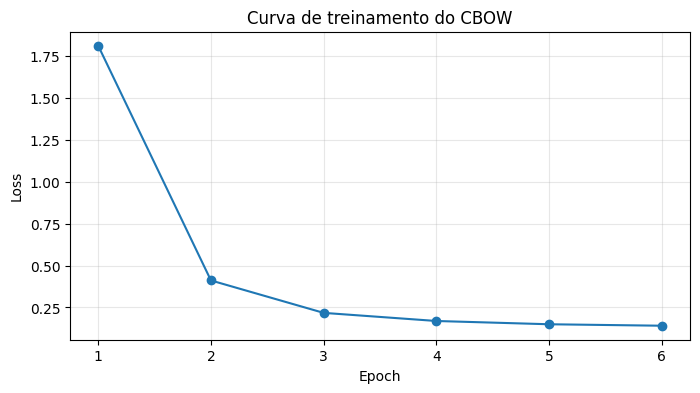

In [8]:

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(history) + 1), history, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Curva de treinamento do CBOW")
plt.grid(True, alpha=0.3)
plt.show()



## 5. Fazendo previsões


In [9]:

@torch.no_grad()
def predict_center_word(context_words, topk=5):
    model.eval()
    context_ids = torch.tensor([[encode(w) for w in context_words]], dtype=torch.long, device=device)
    logits = model(context_ids)
    probs = torch.softmax(logits, dim=-1)
    values, indices = torch.topk(probs, k=topk, dim=-1)
    return [(decode(idx.item()), float(prob.item())) for prob, idx in zip(values[0], indices[0])]

examples = [
    ["the", "king", "a", "woman"],
    ["python", "is", "programming", "language"],
    ["the", "cat", "a", "domestic"],
]

for ex in examples:
    print("Contexto:", ex)
    print("Previsões:", predict_center_word(ex))
    print()


Contexto: ['the', 'king', 'a', 'woman']
Previsões: [('is', 0.9960467219352722), ('prince', 0.0028864091727882624), ('woman', 0.0007300898432731628), ('rules', 0.00011870429443661124), ('king', 7.009406544966623e-05)]

Contexto: ['python', 'is', 'programming', 'language']
Previsões: [('a', 0.9975594282150269), ('pytorch', 0.00185102759860456), ('bone', 0.00020299114112276584), ('library', 0.00014494261995423585), ('likes', 0.00010939299681922421)]

Contexto: ['the', 'cat', 'a', 'domestic']
Previsões: [('is', 0.5449841022491455), ('animal', 0.45255330204963684), ('castle', 0.001391274039633572), ('likes', 0.000565213558729738), ('and', 0.0002424026606604457)]




## 6. Vizinhos mais próximos no espaço vetorial


In [10]:

@torch.no_grad()
def nearest_neighbors(word, topk=5):
    if word not in stoi:
        raise ValueError(f"Palavra {word!r} não está no vocabulário.")

    emb = model.embedding.weight.detach().cpu()
    emb = emb / emb.norm(dim=1, keepdim=True).clamp_min(1e-12)

    query = emb[stoi[word]]
    sims = emb @ query
    values, indices = torch.topk(sims, k=topk + 1)

    result = []
    for sim, idx in zip(values.tolist(), indices.tolist()):
        token = decode(idx)
        if token == word:
            continue
        result.append((token, sim))
        if len(result) == topk:
            break
    return result

for word in ["king", "queen", "python", "cat"]:
    print(word, "->", nearest_neighbors(word))


king -> [('prince', 0.4021013677120209), ('woman', 0.24983322620391846), ('deep', 0.2424577921628952), ('in', 0.23049868643283844), ('from', 0.22438661754131317)]
queen -> [('princess', 0.5376037359237671), ('kingdom', 0.3656419813632965), ('castle', 0.33907055854797363), ('from', 0.2859748899936676), ('<UNK>', 0.28486859798431396)]
python -> [('programming', 0.3237002193927765), ('deep', 0.30111441016197205), ('in', 0.28045573830604553), ('cat', 0.27685055136680603), ('learning', 0.2738942503929138)]
cat -> [('dog', 0.3817645311355591), ('python', 0.27685055136680603), ('prince', 0.2383144497871399), ('learning', 0.21941757202148438), ('lives', 0.21144607663154602)]
